**🎀 AI-Powered Job Readiness & Skill-to-Role Recommendation System**

---

**Project Overview:**  
This notebook builds a complete machine learning pipeline that:
- Predicts whether a student/candidate is **Job Ready** based on their profile
- Recommends the **Top 3 most suitable job roles** using Cosine Similarity
- Performs **Skill Gap Analysis** for a target role
- Accepts **manual user input** for real-time prediction

**Dataset:** 8,000 rows of synthetic but realistic candidate profiles  
**Models:** Logistic Regression, Random Forest, XGBoost, Decision Tree

---

## **Importing Libraries**

In [36]:
import numpy as np
import pandas as pd
import random
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from scipy.sparse import hstack, csr_matrix

#  XGBoost
!pip install xgboost -q
from xgboost import XGBClassifier

print('All libraries were imported successfully, yay!')

All libraries were imported successfully, yay!


---
## **Dataset Creation**
---

In [63]:
np.random.seed(42)
random.seed(42)

N = 8000

SKILL_POOL = {
    'data_analyst':         ['Python', 'SQL', 'Excel', 'Tableau', 'Power BI', 'Statistics',
                             'R', 'Data Cleaning', 'Pandas', 'NumPy'],
    'software_developer':   ['Java', 'C++', 'Python', 'Git', 'OOP', 'Data Structures',
                             'Algorithms', 'Linux', 'REST API', 'Unit Testing'],
    'ml_engineer':          ['Python', 'Machine Learning', 'Deep Learning', 'TensorFlow',
                             'Scikit-learn', 'PyTorch', 'NLP', 'SQL', 'Statistics', 'Pandas'],
    'web_developer':        ['HTML', 'CSS', 'JavaScript', 'React', 'Node.js', 'Git',
                             'MongoDB', 'REST API', 'Bootstrap', 'TypeScript'],
    'backend_developer':    ['Python', 'Django', 'Flask', 'SQL', 'REST API', 'Docker',
                             'Kubernetes', 'Git', 'Linux', 'Microservices'],
    'business_analyst':     ['Excel', 'SQL', 'Statistics', 'Power BI', 'Tableau',
                             'Communication', 'Data Analysis', 'Business Intelligence',
                             'Project Management', 'JIRA'],
    'cloud_engineer':       ['AWS', 'Azure', 'GCP', 'Docker', 'Kubernetes', 'Terraform',
                             'Linux', 'CI/CD', 'Python', 'Networking']
}

ALL_SKILLS = list({s for skills in SKILL_POOL.values() for s in skills})

CERT_POOL = [
    'AWS Certified', 'Google Cloud Certified', 'Azure Fundamentals',
    'TensorFlow Developer', 'Meta Front-End Developer',
    'IBM Data Science', 'Coursera ML Specialization',
    'Oracle Java SE', 'Cisco Networking', 'PMI Agile',
    'None'
]

PROJECT_POOL = [
    'E-commerce Website', 'Sentiment Analysis', 'Chatbot Development',
    'Image Classifier', 'Sales Dashboard', 'Inventory Management System',
    'REST API Service', 'Portfolio Website', 'Data Pipeline',
    'Stock Price Predictor', 'Face Recognition', 'Recommendation Engine',
    'Cloud Deployment', 'Budget Tracker', 'Job Portal'
]

ROLES = list(SKILL_POOL.keys())
ROLE_LABELS = [
    'Data Analyst', 'Software Developer', 'ML Engineer',
    'Web Developer', 'Backend Developer', 'Business Analyst', 'Cloud Engineer'
]

def pick(pool, lo, hi):
    return ', '.join(random.sample(pool, k=random.randint(lo, hi)))

rows = []
for i in range(N):

    role_key  = random.choice(ROLES)
    role_label = ROLE_LABELS[ROLES.index(role_key)]

    core_skills = random.sample(SKILL_POOL[role_key],
                                k=random.randint(2, len(SKILL_POOL[role_key])))
    extra_skills = random.sample(ALL_SKILLS,
                                 k=random.randint(0, 3))
    skills = ', '.join(list(dict.fromkeys(core_skills + extra_skills)))

    n_skills       = len(set(skills.split(', ')))
    n_projects     = random.randint(0, 6)
    n_certs        = random.randint(0, 3)
    cgpa           = round(np.clip(np.random.normal(7.2, 1.0), 4.0, 10.0), 2)
    n_internships  = random.randint(0, 3)
    comm           = random.randint(1, 10)
    aptitude       = random.randint(30, 100)
    problem_solving= random.randint(1, 10)

    certs_str    = pick(CERT_POOL[:-1], 0, min(n_certs, len(CERT_POOL)-2)) if n_certs else 'None'
    projects_str = pick(PROJECT_POOL, 1, min(n_projects+1, len(PROJECT_POOL))) if n_projects else 'None'

    score = (
        (cgpa - 4.0) / 6.0           * 25  +
        min(n_skills / 10, 1.0)      * 20  +
        min(n_projects / 5, 1.0)     * 15  +
        min(n_internships / 3, 1.0)  * 15  +
        min(n_certs / 3, 1.0)        * 10  +
        comm / 10                    * 8   +
        (aptitude - 30) / 70         * 7
    )

    score += np.random.normal(0, 5)
    score  = np.clip(score, 0, 100)

    job_ready = 'Yes' if score >= 50 else 'No'

    rows.append({
        'Skills':               skills,
        'Projects':             projects_str,
        'Certifications':       certs_str,
        'CGPA':                 cgpa,
        'Internships':          n_internships,
        'Communication_Skills': comm,
        'Aptitude_Score':       aptitude,
        'Problem_Solving':      problem_solving,
        'Role_Interest':        role_label,
        'Job_Ready':            job_ready
    })

df = pd.DataFrame(rows)

df.to_csv('job_readiness_dataset.csv', index=False)
print(f'Dataset created and saved!  Shape: {df.shape}')
print(f'Job_Ready distribution:\n{df["Job_Ready"].value_counts()}')
df.head(5)

Dataset created and saved!  Shape: (8000, 10)
Job_Ready distribution:
Job_Ready
Yes    5599
No     2401
Name: count, dtype: int64


,Skills,Projects,Certifications,CGPA,Internships,Communication_Skills,Aptitude_Score,Problem_Solving,Role_Interest,Job_Ready
0,"Excel, Tableau, Power BI, Data Structures",Sentiment Analysis,None,7.70,0,10,84,1,Business Analyst,Yes
1,"REST API, Java, Git, Data Structures, Algorith...",Image Classifier,None,7.85,1,7,73,5,Software Developer,Yes
2,"Azure, Networking, Linux, AWS, GCP, Terraform,...","Image Classifier, Recommendation Engine, Senti...","PMI Agile, IBM Data Science",6.97,0,7,40,9,Cloud Engineer,Yes
3,"C++, Git, Unit Testing, REST API, Python, Algo...",Portfolio Website,,8.78,2,2,51,9,Software Developer,Yes
4,"Bootstrap, React, Git, MongoDB, HTML, CSS","Portfolio Website, REST API Service, Face Reco...","IBM Data Science, TensorFlow Developer",6.73,3,5,38,4,Web Developer,Yes


## **Data Preprocessing**

In [67]:
print('Dataset Info')
df.info()
print('\nMissing Values')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Skills                8000 non-null   object 
 1   Projects              8000 non-null   object 
 2   Certifications        8000 non-null   object 
 3   CGPA                  8000 non-null   float64
 4   Internships           8000 non-null   int64  
 5   Communication_Skills  8000 non-null   int64  
 6   Aptitude_Score        8000 non-null   int64  
 7   Problem_Solving       8000 non-null   int64  
 8   Role_Interest         8000 non-null   object 
 9   Job_Ready             8000 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 625.1+ KB

Missing Values
Skills                  0
Projects                0
Certifications          0
CGPA                    0
Internships             0
Communication_Skills    0
Aptitude_Score          0
Proble

In [71]:
df.drop_duplicates(inplace=True)
df.fillna('None', inplace=True)

le_target = LabelEncoder()
df['Job_Ready_Enc'] = le_target.fit_transform(df['Job_Ready'])

le_role = LabelEncoder()
df['Role_Interest_Enc'] = le_role.fit_transform(df['Role_Interest'])

print('Target classes:', le_target.classes_)
print('Roles encoded:',  le_role.classes_)

tfidf_skills = TfidfVectorizer(max_features=50, analyzer='word',
                               token_pattern=r'[^,]+')
tfidf_proj   = TfidfVectorizer(max_features=20, analyzer='word',
                               token_pattern=r'[^,]+')
tfidf_cert   = TfidfVectorizer(max_features=15, analyzer='word',
                               token_pattern=r'[^,]+')

X_skills = tfidf_skills.fit_transform(df['Skills'])
X_proj   = tfidf_proj  .fit_transform(df['Projects'])
X_cert   = tfidf_cert  .fit_transform(df['Certifications'])

num_cols = ['CGPA', 'Internships', 'Communication_Skills',
            'Aptitude_Score', 'Problem_Solving', 'Role_Interest_Enc']

scaler  = StandardScaler()
X_num   = csr_matrix(scaler.fit_transform(df[num_cols]))

X = hstack([X_skills, X_proj, X_cert, X_num])
y = df['Job_Ready_Enc'].values

print(f'\nFeature matrix shape: {X.shape}')
print(f'Target distribution  — 0 (No): {(y==0).sum()}  |  1 (Yes): {(y==1).sum()}')

Target classes: ['No' 'Yes']
Roles encoded: ['Backend Developer' 'Business Analyst' 'Cloud Engineer' 'Data Analyst'
 'ML Engineer' 'Software Developer' 'Web Developer']

Feature matrix shape: (8000, 91)
Target distribution  — 0 (No): 2401  |  1 (Yes): 5599


---
## **Exploratory Data Analysis (EDA)**

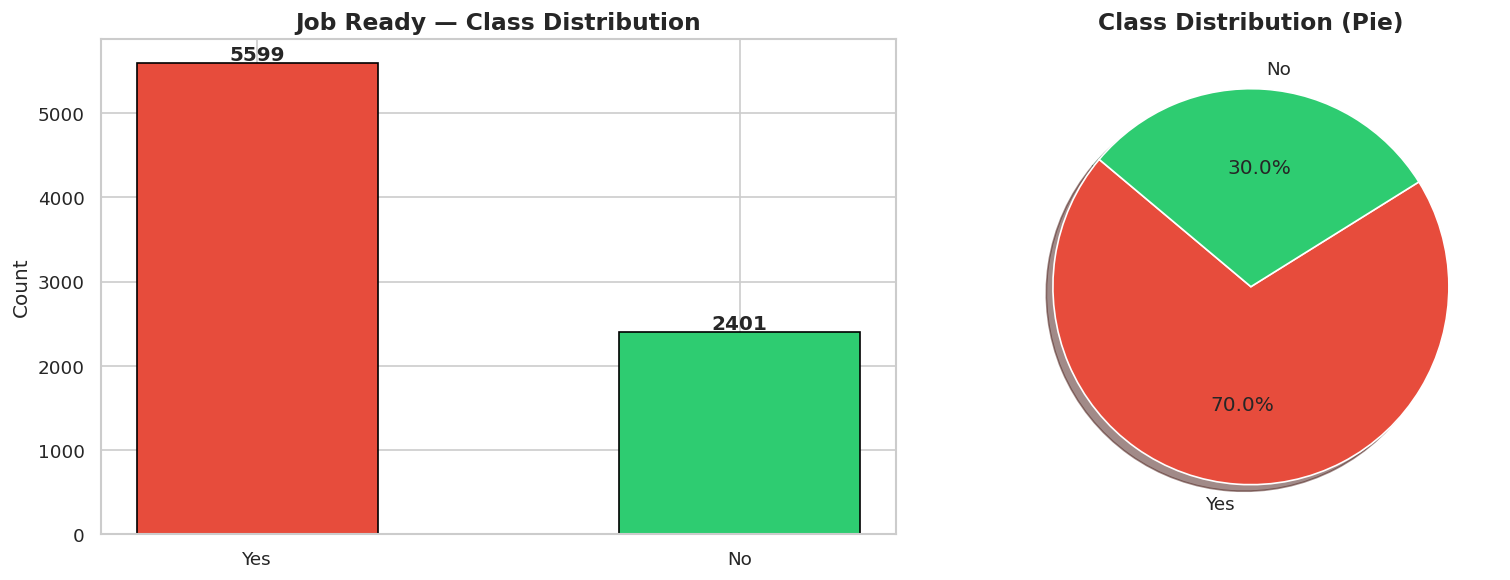

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Job_Ready'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#E74C3C', '#2ECC71'], edgecolor='black', width=0.5)
axes[0].set_title('Job Ready — Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=['#E74C3C', '#2ECC71'],
            startangle=140, shadow=True)
axes[1].set_title('Class Distribution (Pie)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

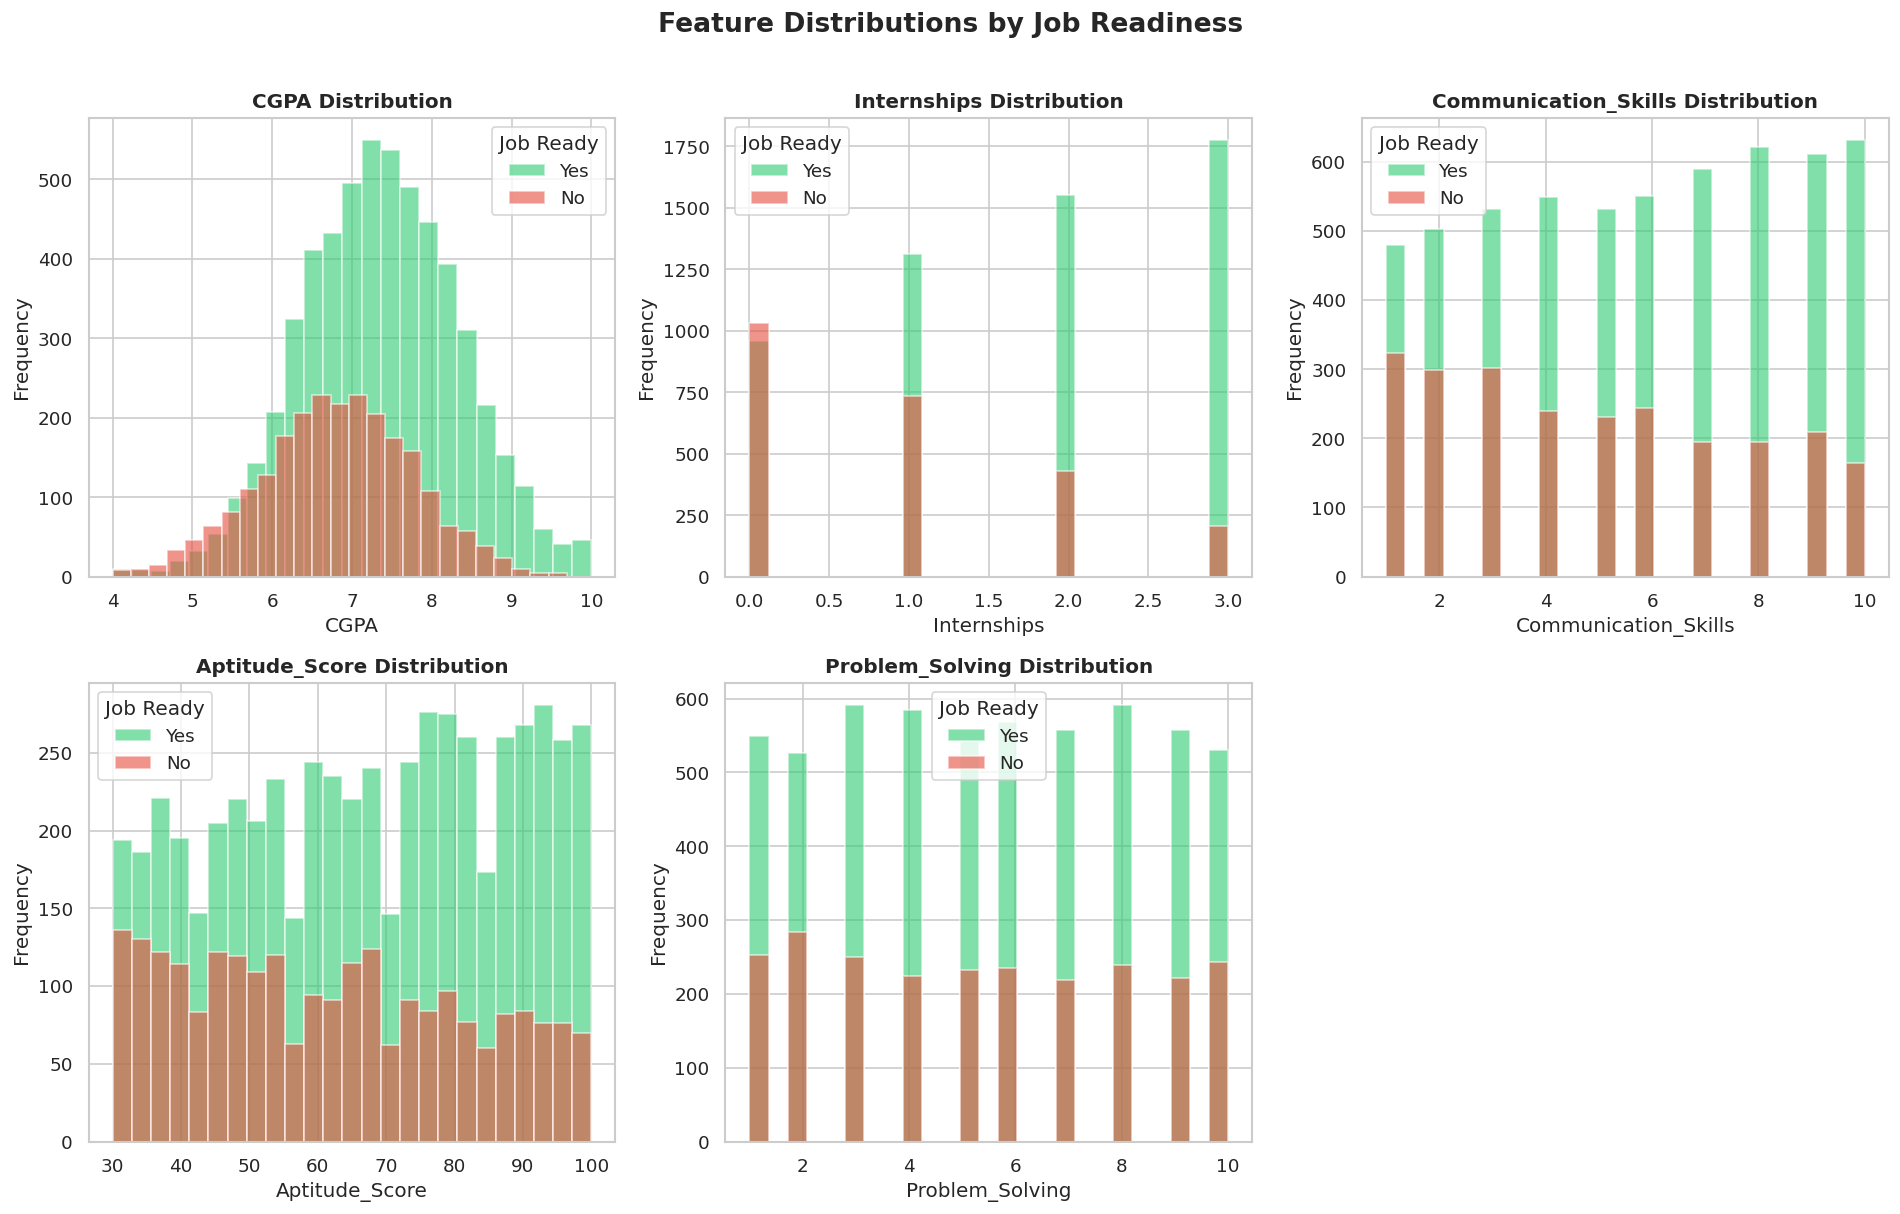

In [73]:
num_features = ['CGPA', 'Internships', 'Communication_Skills',
                'Aptitude_Score', 'Problem_Solving']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(num_features):
    for label, color in [('Yes','#2ECC71'), ('No','#E74C3C')]:
        axes[idx].hist(df[df['Job_Ready']==label][col],
                       bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[idx].set_title(f'{col} Distribution', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(title='Job Ready')

axes[5].axis('off')
plt.suptitle('Feature Distributions by Job Readiness', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

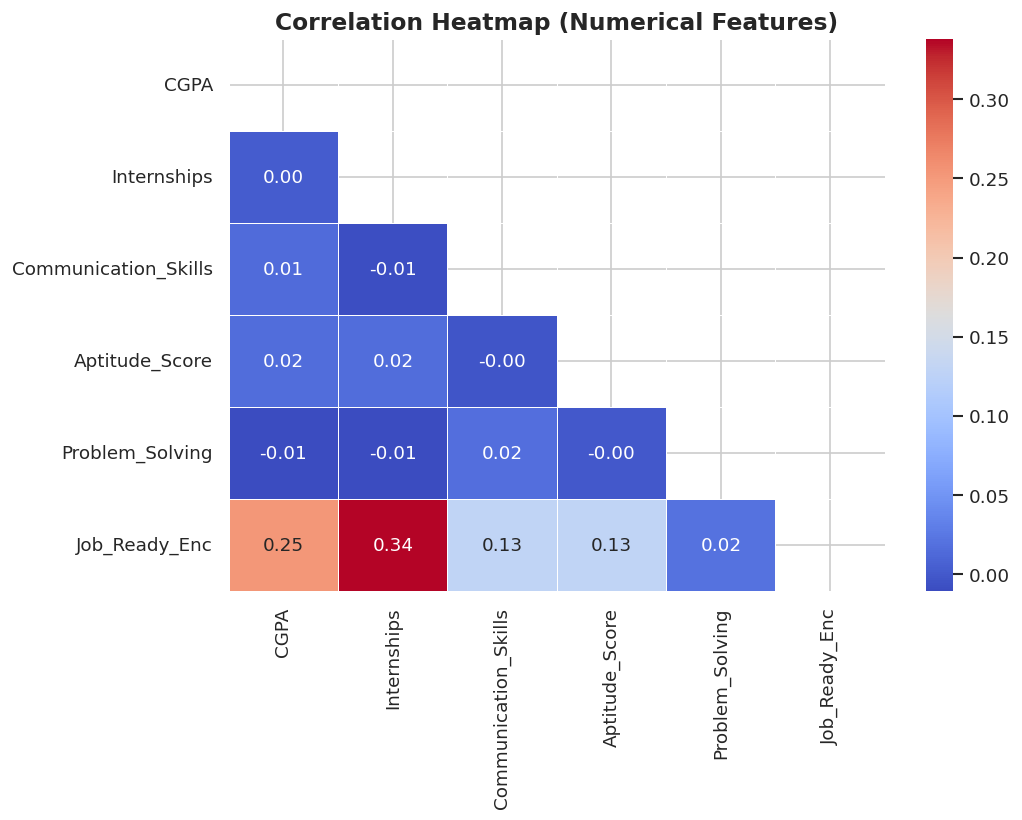

In [74]:
corr_df = df[num_features + ['Job_Ready_Enc']].copy()
corr    = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, mask=mask, ax=ax,
            annot_kws={'size': 11})
ax.set_title('Correlation Heatmap (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

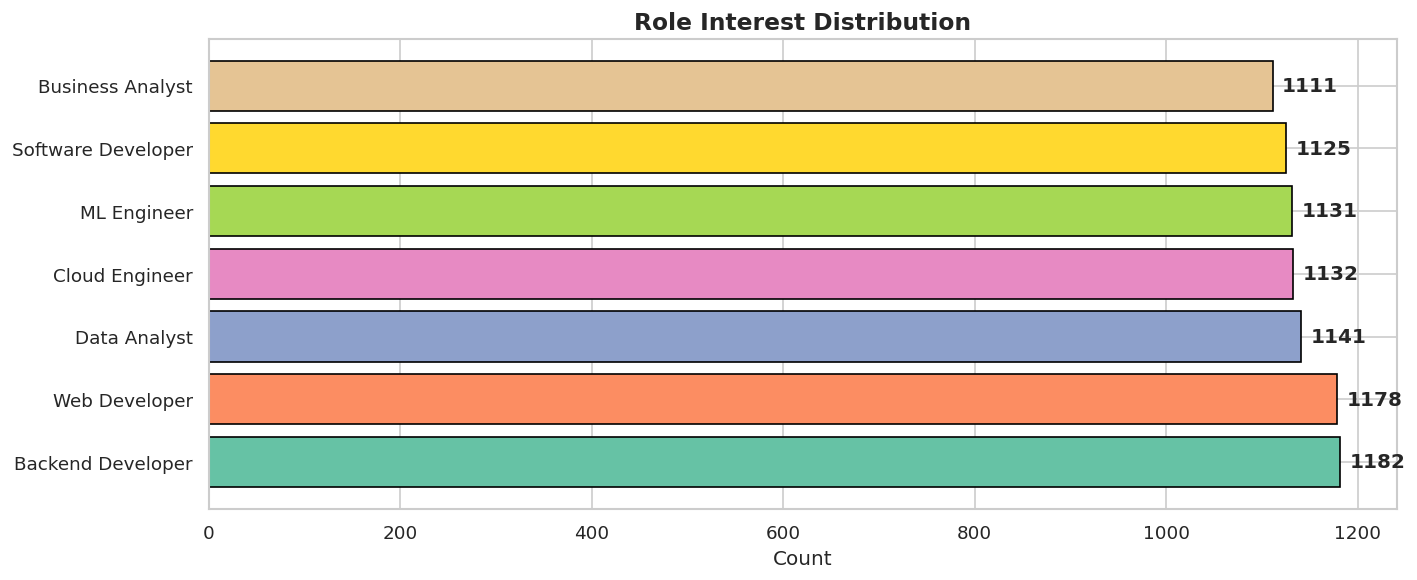

In [75]:
role_counts = df['Role_Interest'].value_counts()
colors_roles = sns.color_palette('Set2', len(role_counts))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(role_counts.index, role_counts.values,
               color=colors_roles, edgecolor='black')
ax.set_title('Role Interest Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
for bar, val in zip(bars, role_counts.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

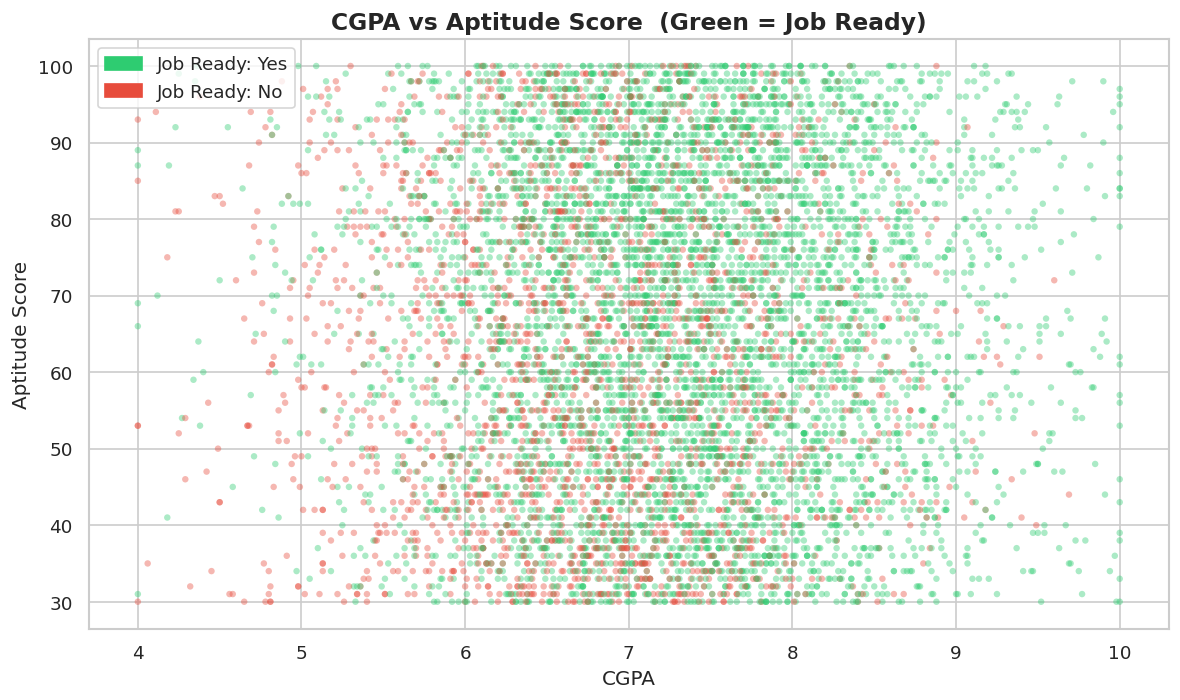

In [76]:

fig, ax = plt.subplots(figsize=(10, 6))
colors = df['Job_Ready'].map({'Yes': '#2ECC71', 'No': '#E74C3C'})
ax.scatter(df['CGPA'], df['Aptitude_Score'],
           c=colors, alpha=0.4, s=15, edgecolors='none')
ax.set_xlabel('CGPA', fontsize=12)
ax.set_ylabel('Aptitude Score', fontsize=12)
ax.set_title('CGPA vs Aptitude Score  (Green = Job Ready)', fontsize=14, fontweight='bold')
green_patch = mpatches.Patch(color='#2ECC71', label='Job Ready: Yes')
red_patch   = mpatches.Patch(color='#E74C3C', label='Job Ready: No')
ax.legend(handles=[green_patch, red_patch])
plt.tight_layout()
plt.show()

---
## **Train-Test Split**

In [77]:
# 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test  size : {X_test.shape[0]} rows')
print(f'Train — No: {(y_train==0).sum()}  Yes: {(y_train==1).sum()}')
print(f'Test  — No: {(y_test ==0).sum()}  Yes: {(y_test ==1).sum()}')

Train size : 6400 rows
Test  size : 1600 rows
Train — No: 1921  Yes: 4479
Test  — No: 480  Yes: 1120


---
## **Model Training**

In [78]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=12, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=15,
                                                  random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy':  accuracy_score (y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score   (y_test, y_pred),
        'F1 Score':  f1_score       (y_test, y_pred),
        'ROC-AUC':   roc_auc_score  (y_test, y_proba),
        'model_obj': model
    }
    print(f'{name:<22} | Acc: {results[name]["Accuracy"]:.4f}  '
          f'F1: {results[name]["F1 Score"]:.4f}  ROC-AUC: {results[name]["ROC-AUC"]:.4f}')

Logistic Regression    | Acc: 0.8325  F1: 0.8839  ROC-AUC: 0.9070
Decision Tree          | Acc: 0.7462  F1: 0.8232  ROC-AUC: 0.6741
Random Forest          | Acc: 0.7987  F1: 0.8703  ROC-AUC: 0.8833
XGBoost                | Acc: 0.8125  F1: 0.8707  ROC-AUC: 0.8821


---
## **Model Comparison**

In [79]:
metrics_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k != 'model_obj'}
    for name, vals in results.items()
}).T.round(4)

print('=== Model Comparison Table ===')
print(metrics_df.to_string())

=== Model Comparison Table ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.8325     0.8586  0.9107    0.8839   0.9070
Decision Tree          0.7462     0.8036  0.8438    0.8232   0.6741
Random Forest          0.7988     0.7930  0.9643    0.8703   0.8833
XGBoost                0.8125     0.8417  0.9018    0.8707   0.8821


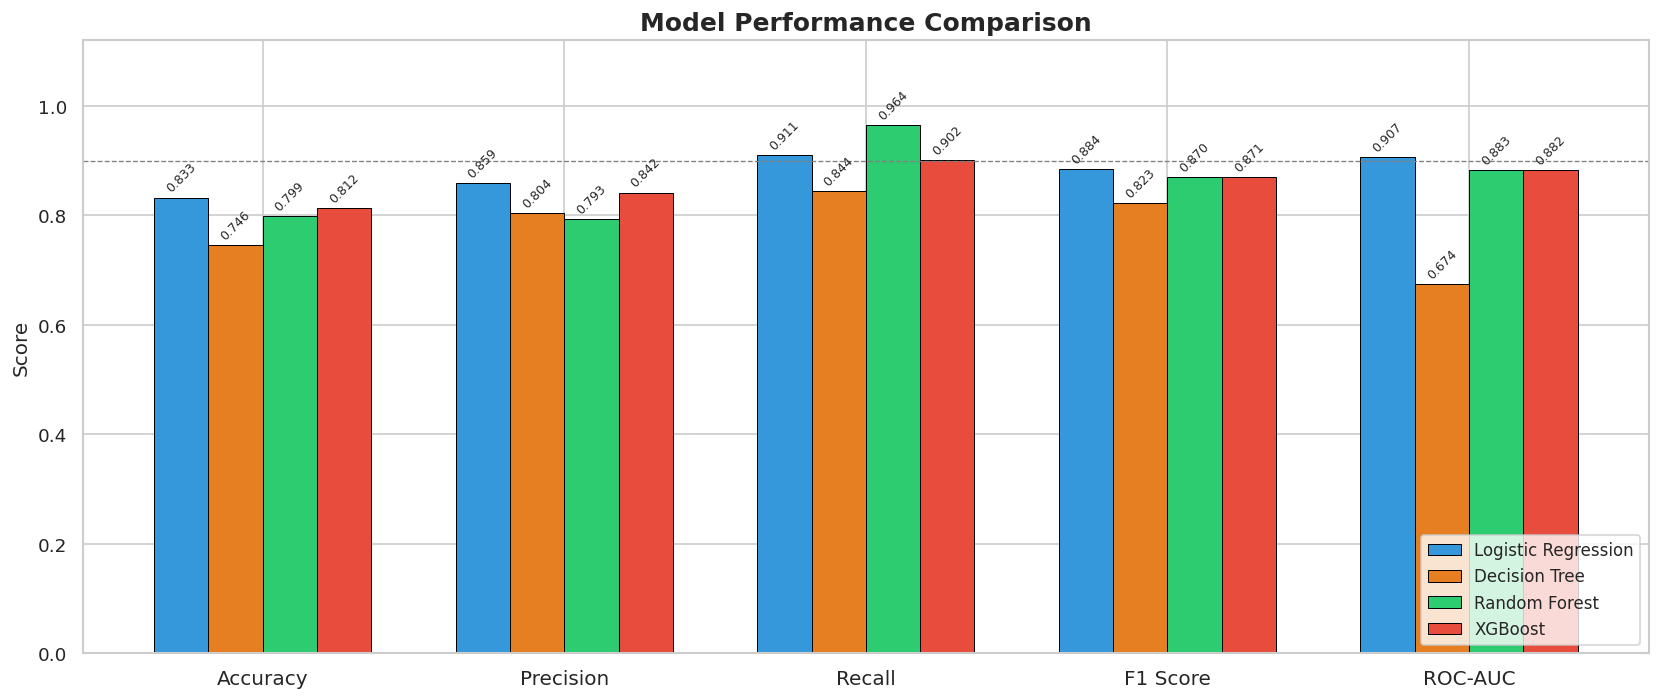

In [80]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metric_cols))
width = 0.18
palette = ['#3498DB', '#E67E22', '#2ECC71', '#E74C3C']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, row) in enumerate(metrics_df.iterrows()):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, row[metric_cols], width,
                  label=name, color=palette[i], edgecolor='black', linewidth=0.6)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.axhline(0.9, ls='--', color='gray', linewidth=0.8, label='0.90 threshold')
plt.tight_layout()
plt.show()

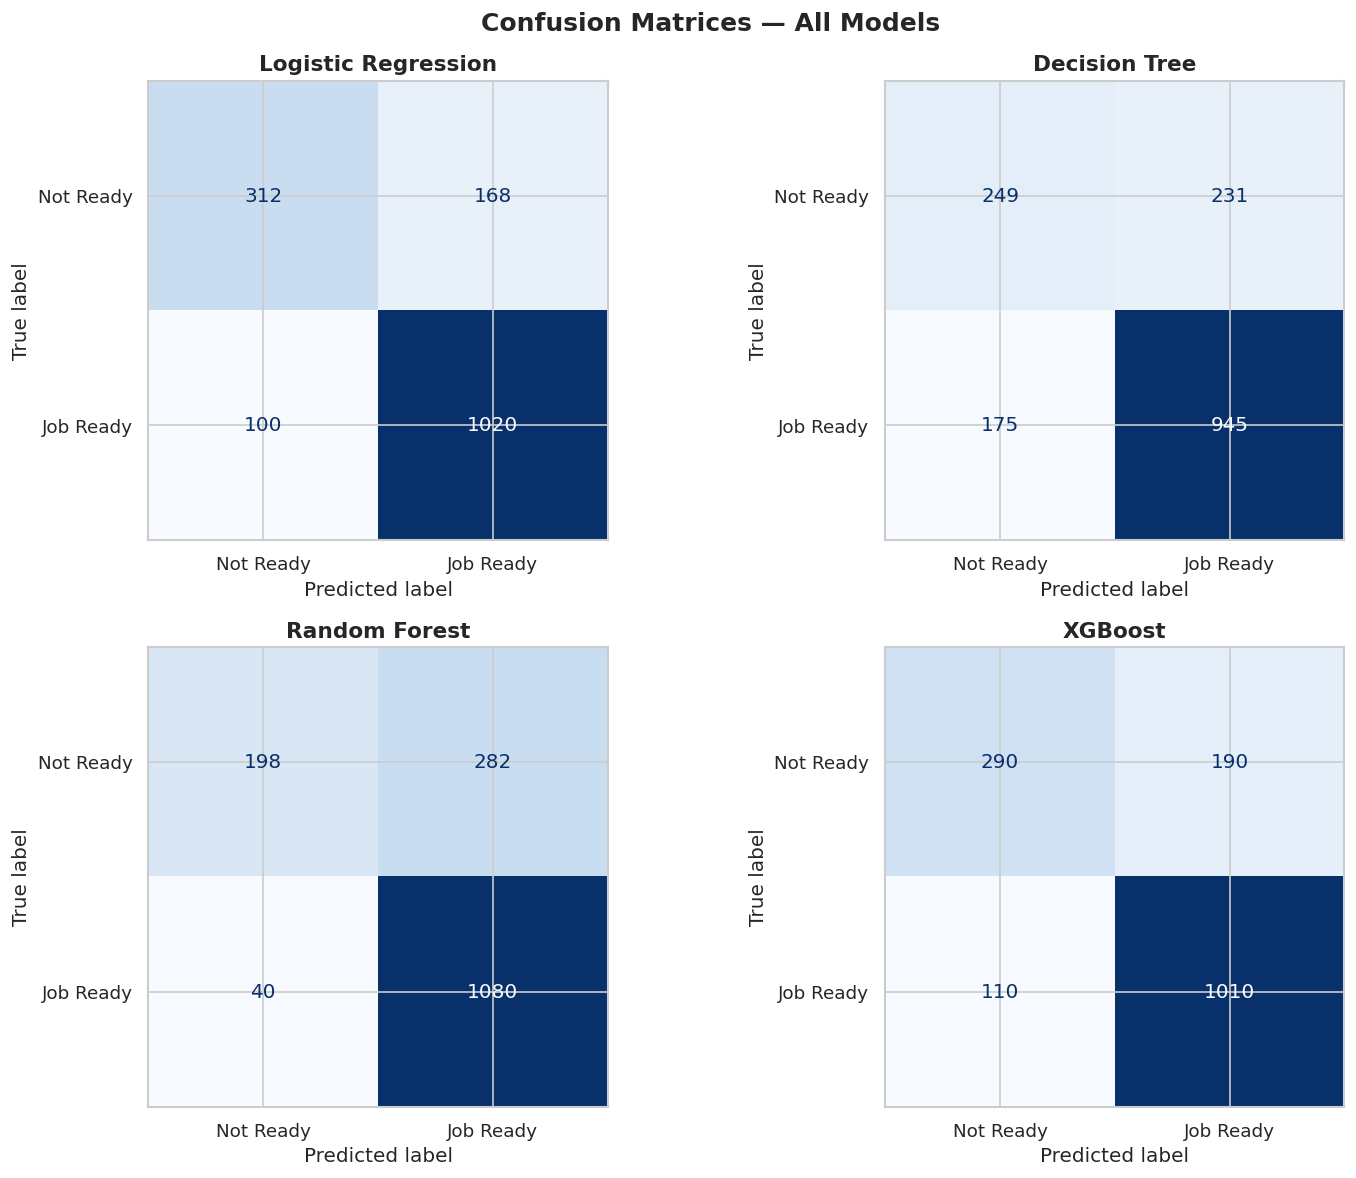

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for idx, (name, vals) in enumerate(results.items()):
    model  = vals['model_obj']
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Ready', 'Job Ready'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **Hyperparameter Tuning**

In [83]:
best_name = metrics_df['ROC-AUC'].idxmax()
print(f'Best model by ROC-AUC: {best_name}')

param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth':    [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'n_estimators':  [100, 200, 300],
        'max_depth':     [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample':     [0.7, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.9, 1.0]
    },
    'Decision Tree': {
        'max_depth':         [8, 12, 16, 20],
        'min_samples_split': [2, 5, 10],
        'criterion':         ['gini', 'entropy']
    },
    'Logistic Regression': {
        'C':        [0.01, 0.1, 1, 10, 100],
        'solver':   ['lbfgs', 'saga'],
        'max_iter': [500, 1000]
    }
}

base_model = results[best_name]['model_obj']
param_grid = param_grids.get(best_name, {})

if param_grid:
    print(f'   Running RandomizedSearchCV (20 iterations, 3-fold CV)…')
    rs = RandomizedSearchCV(
        estimator=base_model.__class__(
            **({} if best_name == 'Logistic Regression' else
               {'random_state': 42, 'n_jobs': -1} if best_name in ('Random Forest',) else
               {'use_label_encoder': False, 'eval_metric': 'logloss',
                'random_state': 42, 'n_jobs': -1} if best_name == 'XGBoost' else
               {'random_state': 42})
        ),
        param_distributions=param_grid,
        n_iter=20, cv=3, scoring='roc_auc',
        n_jobs=-1, verbose=1, random_state=42
    )
    rs.fit(X_train, y_train)

    best_tuned = rs.best_estimator_
    y_pred_t   = best_tuned.predict(X_test)
    y_proba_t  = best_tuned.predict_proba(X_test)[:, 1]

    print(f'\n   Best params : {rs.best_params_}')
    print(f'   Tuned Accuracy : {accuracy_score(y_test, y_pred_t):.4f}')
    print(f'   Tuned ROC-AUC  : {roc_auc_score(y_test, y_proba_t):.4f}')
    print(f'   Tuned F1 Score : {f1_score(y_test, y_pred_t):.4f}')

    # Use tuned model going forward
    final_model = best_tuned
else:
    final_model = base_model

print(f'\n🚀 Final model selected: {best_name}')

Best model by ROC-AUC: Logistic Regression
   Running RandomizedSearchCV (20 iterations, 3-fold CV)…
Fitting 3 folds for each of 20 candidates, totalling 60 fits

   Best params : {'solver': 'lbfgs', 'max_iter': 500, 'C': 100}
   Tuned Accuracy : 0.8375
   Tuned ROC-AUC  : 0.9096
   Tuned F1 Score : 0.8871

🚀 Final model selected: Logistic Regression


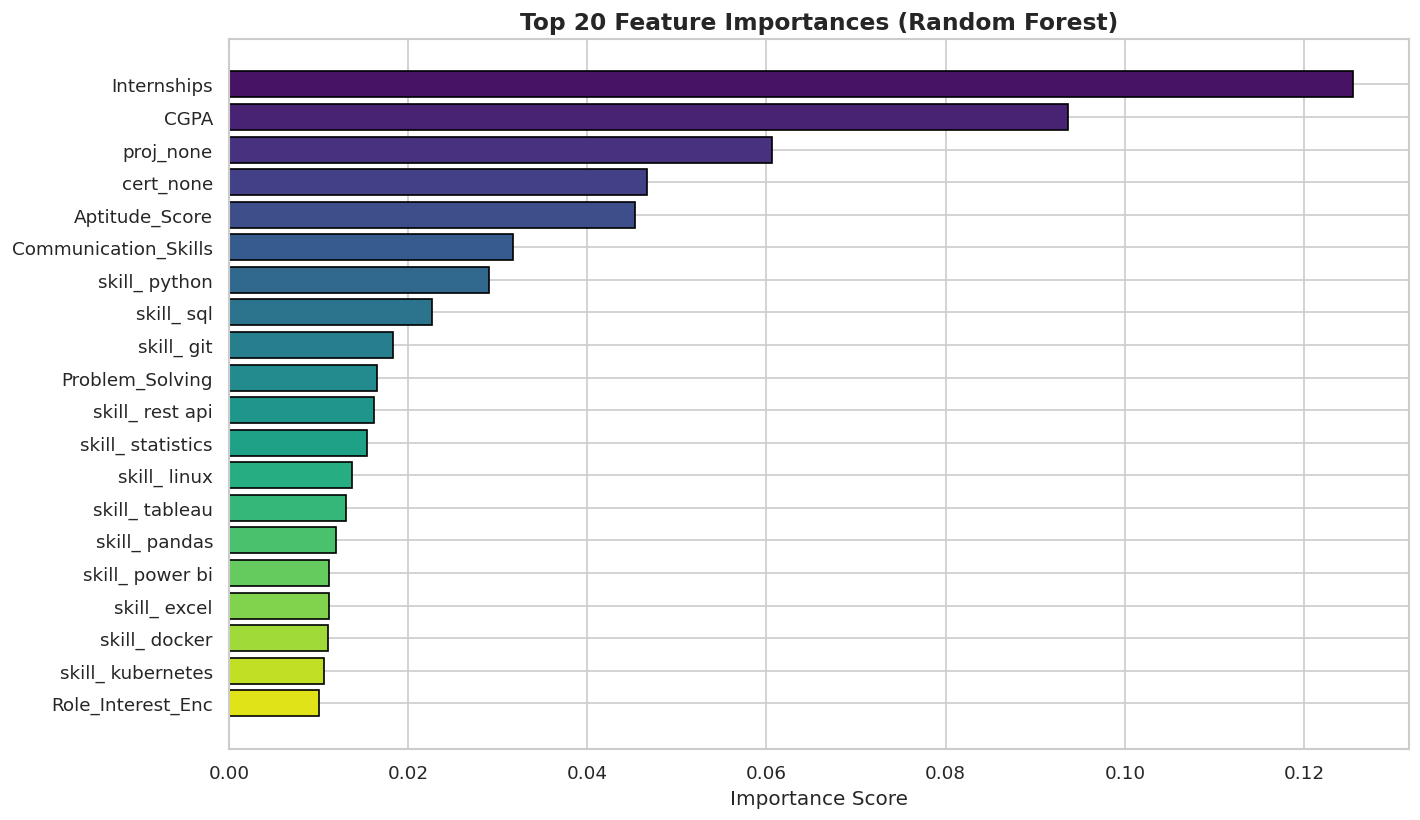

In [84]:
rf_model = results['Random Forest']['model_obj']

skill_names  = [f'skill_{n}'  for n in tfidf_skills.get_feature_names_out()]
proj_names   = [f'proj_{n}'   for n in tfidf_proj  .get_feature_names_out()]
cert_names   = [f'cert_{n}'   for n in tfidf_cert  .get_feature_names_out()]
feat_names   = skill_names + proj_names + cert_names + num_cols

importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors  = sns.color_palette('viridis', len(feat_imp_df))
ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
        color=colors[::-1], edgecolor='black')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **Job Role Recommendation System (Cosine Similarity)**

In [52]:
ROLE_SKILL_STRINGS = {
    'Data Analyst':       'Python SQL Excel Tableau Power BI Statistics R Data Cleaning Pandas NumPy',
    'Software Developer': 'Java C++ Python Git OOP Data Structures Algorithms Linux REST API Unit Testing',
    'ML Engineer':        'Python Machine Learning Deep Learning TensorFlow Scikit-learn PyTorch NLP SQL Statistics Pandas',
    'Web Developer':      'HTML CSS JavaScript React Node.js Git MongoDB REST API Bootstrap TypeScript',
    'Backend Developer':  'Python Django Flask SQL REST API Docker Kubernetes Git Linux Microservices',
    'Business Analyst':   'Excel SQL Statistics Power BI Tableau Communication Data Analysis Business Intelligence Project Management JIRA',
    'Cloud Engineer':     'AWS Azure GCP Docker Kubernetes Terraform Linux CI/CD Python Networking'
}

role_names   = list(ROLE_SKILL_STRINGS.keys())
role_strings = list(ROLE_SKILL_STRINGS.values())

tfidf_rec = TfidfVectorizer()
all_docs   = role_strings + df['Skills'].tolist()
tfidf_rec.fit(all_docs)

role_vectors = tfidf_rec.transform(role_strings)  # shape (7, vocab)

def recommend_roles(skill_string, top_n=3):
    """Return top_n role names and their similarity scores."""
    user_vec  = tfidf_rec.transform([skill_string])
    sims      = cosine_similarity(user_vec, role_vectors).flatten()
    top_idx   = sims.argsort()[::-1][:top_n]
    return [(role_names[i], round(sims[i] * 100, 2)) for i in top_idx]

demo_skills = 'Python Machine Learning TensorFlow SQL Pandas Deep Learning'
print(f'Demo skills: "{demo_skills}"\n')
print('Top 3 Recommended Roles:')
for rank, (role, score) in enumerate(recommend_roles(demo_skills), 1):
    print(f'  {rank}. {role:<22} — Similarity: {score}%')

Demo skills: "Python Machine Learning TensorFlow SQL Pandas Deep Learning"

Top 3 Recommended Roles:
  1. ML Engineer            — Similarity: 79.13%
  2. Data Analyst           — Similarity: 19.34%
  3. Backend Developer      — Similarity: 9.94%


---
## **Skill Gap Analysis**

In [86]:
ROLE_REQUIRED_SKILLS = {
    'Data Analyst':       ['Python', 'SQL', 'Excel', 'Tableau', 'Power BI', 'Statistics', 'R', 'Data Cleaning', 'Pandas', 'NumPy'],
    'Software Developer': ['Java', 'C++', 'Python', 'Git', 'OOP', 'Data Structures', 'Algorithms', 'Linux', 'REST API', 'Unit Testing'],
    'ML Engineer':        ['Python', 'Machine Learning', 'Deep Learning', 'TensorFlow', 'Scikit-learn', 'PyTorch', 'NLP', 'SQL', 'Statistics', 'Pandas'],
    'Web Developer':      ['HTML', 'CSS', 'JavaScript', 'React', 'Node.js', 'Git', 'MongoDB', 'REST API', 'Bootstrap', 'TypeScript'],
    'Backend Developer':  ['Python', 'Django', 'Flask', 'SQL', 'REST API', 'Docker', 'Kubernetes', 'Git', 'Linux', 'Microservices'],
    'Business Analyst':   ['Excel', 'SQL', 'Statistics', 'Power BI', 'Tableau', 'Communication', 'Data Analysis', 'Business Intelligence', 'Project Management', 'JIRA'],
    'Cloud Engineer':     ['AWS', 'Azure', 'GCP', 'Docker', 'Kubernetes', 'Terraform', 'Linux', 'CI/CD', 'Python', 'Networking']
}

def skill_gap_analysis(user_skills_str, target_role):
    """Compare user skills against target role requirements."""
    user_skills = {s.strip().lower() for s in user_skills_str.split(',')}
    required    = ROLE_REQUIRED_SKILLS.get(target_role, [])
    have        = [s for s in required if s.lower() in user_skills]
    missing     = [s for s in required if s.lower() not in user_skills]
    coverage    = len(have) / len(required) * 100 if required else 0
    return have, missing, round(coverage, 1)

demo_target = 'ML Engineer'
demo_user_skills = 'Python, SQL, Pandas, TensorFlow, Statistics'
have, missing, coverage = skill_gap_analysis(demo_user_skills, demo_target)

print(f'Target Role: {demo_target}')
print(f'User Skills: {demo_user_skills}')
print(f'\n Skills you HAVE ({len(have)}): {have}')
print(f' Skills MISSING ({len(missing)}): {missing}')
print(f'\n Role Coverage: {coverage}%')

Target Role: ML Engineer
User Skills: Python, SQL, Pandas, TensorFlow, Statistics

 Skills you HAVE (5): ['Python', 'TensorFlow', 'SQL', 'Statistics', 'Pandas']
 Skills MISSING (5): ['Machine Learning', 'Deep Learning', 'Scikit-learn', 'PyTorch', 'NLP']

 Role Coverage: 50.0%


---
## **User Input Prediction**

> **Modify the values below and re-run this cell to get your personalised Job Readiness report.**

In [87]:
user_input = {
    'skills':               'Python, Machine Learning, SQL, TensorFlow, Pandas',
    'projects':             'Image Classifier, Sentiment Analysis',
    'certifications':       'Coursera ML Specialization',
    'cgpa':                 8.2,
    'internships':          1,
    'communication_skills': 7,
    'aptitude_score':       78,
    'problem_solving':      8,
    'role_interest':        'ML Engineer'
}

u_skills = tfidf_skills.transform([user_input['skills']])
u_proj   = tfidf_proj  .transform([user_input['projects']])
u_cert   = tfidf_cert  .transform([user_input['certifications']])

known_roles = list(le_role.classes_)
role_enc    = le_role.transform([user_input['role_interest']])[0] \
              if user_input['role_interest'] in known_roles else 0

u_num_raw = pd.DataFrame([{
    'CGPA':                 user_input['cgpa'],
    'Internships':          user_input['internships'],
    'Communication_Skills': user_input['communication_skills'],
    'Aptitude_Score':       user_input['aptitude_score'],
    'Problem_Solving':      user_input['problem_solving'],
    'Role_Interest_Enc':    role_enc
}])
u_num  = csr_matrix(scaler.transform(u_num_raw))
X_user = hstack([u_skills, u_proj, u_cert, u_num])

prediction  = final_model.predict(X_user)[0]
confidence  = final_model.predict_proba(X_user)[0][1] * 100
label       = le_target.inverse_transform([prediction])[0]

top_roles = recommend_roles(user_input['skills'])

primary_role = top_roles[0][0]
have, missing_skills, coverage = skill_gap_analysis(user_input['skills'], primary_role)

banner = '=' * 55
print(banner)
print('            JOB READINESS REPORT')
print(banner)
status_icon = '✅' if label == 'Yes' else '❌'
print(f'  Job Ready        : {status_icon}  {"YES — You are Job Ready!" if label == "Yes" else "NO  — Keep building your profile"}')
print(f'  Confidence Score : {confidence:.1f}%')
print()
print('   Top 3 Recommended Job Roles:')
for i, (role, sim) in enumerate(top_roles, 1):
    print(f'     {i}. {role:<22}  ({sim}% match)')
print()
print(f'   Skill Gap for "{primary_role}":')
print(f'     Skills you have    : {have}')
print(f'     Skills to acquire  : {missing_skills if missing_skills else "None — You are ready!"}')
print(f'     Role coverage      : {coverage}%')
print(banner)

            JOB READINESS REPORT
  Job Ready        : ✅  YES — You are Job Ready!
  Confidence Score : 92.5%

   Top 3 Recommended Job Roles:
     1. ML Engineer             (69.92% match)
     2. Data Analyst            (25.95% match)
     3. Backend Developer       (13.34% match)

   Skill Gap for "ML Engineer":
     Skills you have    : ['Python', 'Machine Learning', 'TensorFlow', 'SQL', 'Pandas']
     Skills to acquire  : ['Deep Learning', 'Scikit-learn', 'PyTorch', 'NLP', 'Statistics']
     Role coverage      : 50.0%


---
## 📊 Section 12 — Advanced Visualisations

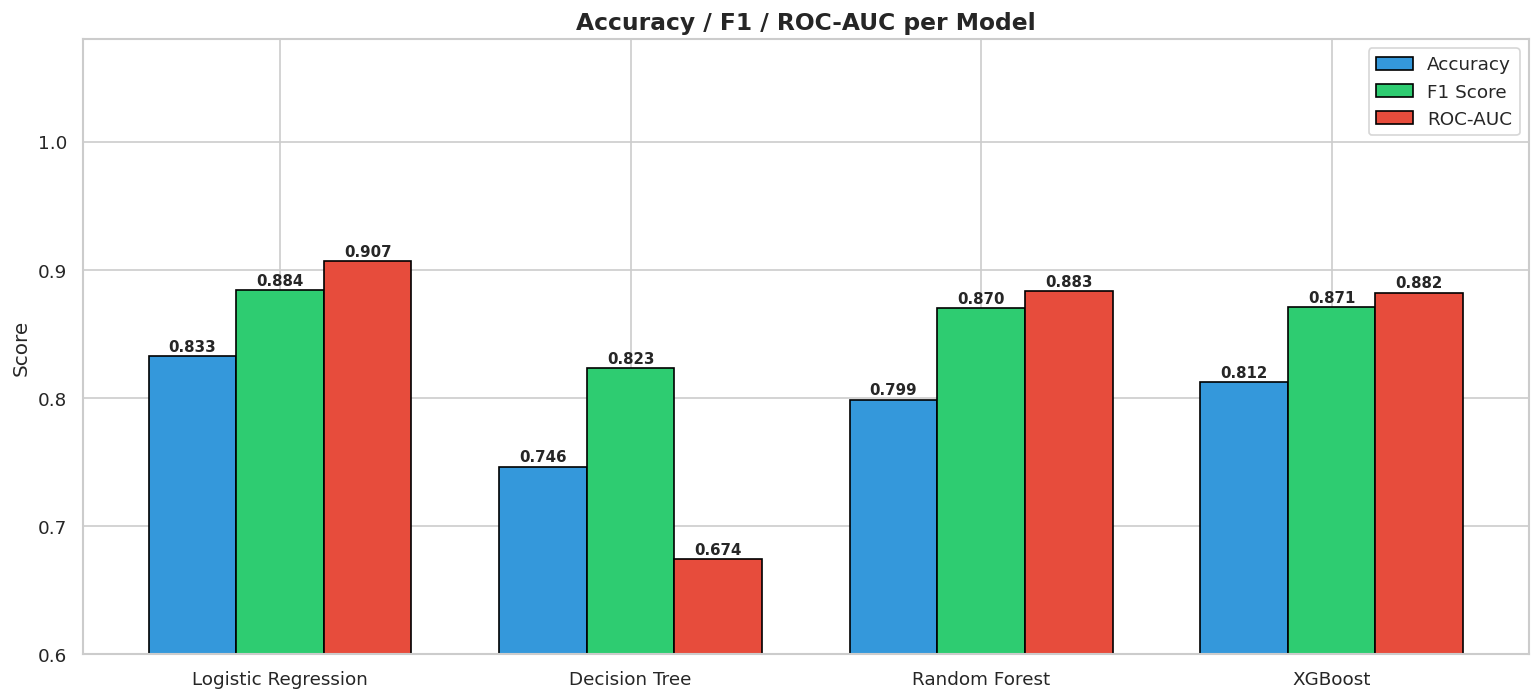

In [88]:
model_names = list(results.keys())
accuracies  = [results[m]['Accuracy'] for m in model_names]
f1_scores   = [results[m]['F1 Score'] for m in model_names]
roc_scores  = [results[m]['ROC-AUC']  for m in model_names]

x = np.arange(len(model_names))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w, accuracies, w, label='Accuracy', color='#3498DB', edgecolor='black')
b2 = ax.bar(x,     f1_scores,  w, label='F1 Score', color='#2ECC71', edgecolor='black')
b3 = ax.bar(x + w, roc_scores, w, label='ROC-AUC',  color='#E74C3C', edgecolor='black')

for bars in (b1, b2, b3):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0.6, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Accuracy / F1 / ROC-AUC per Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

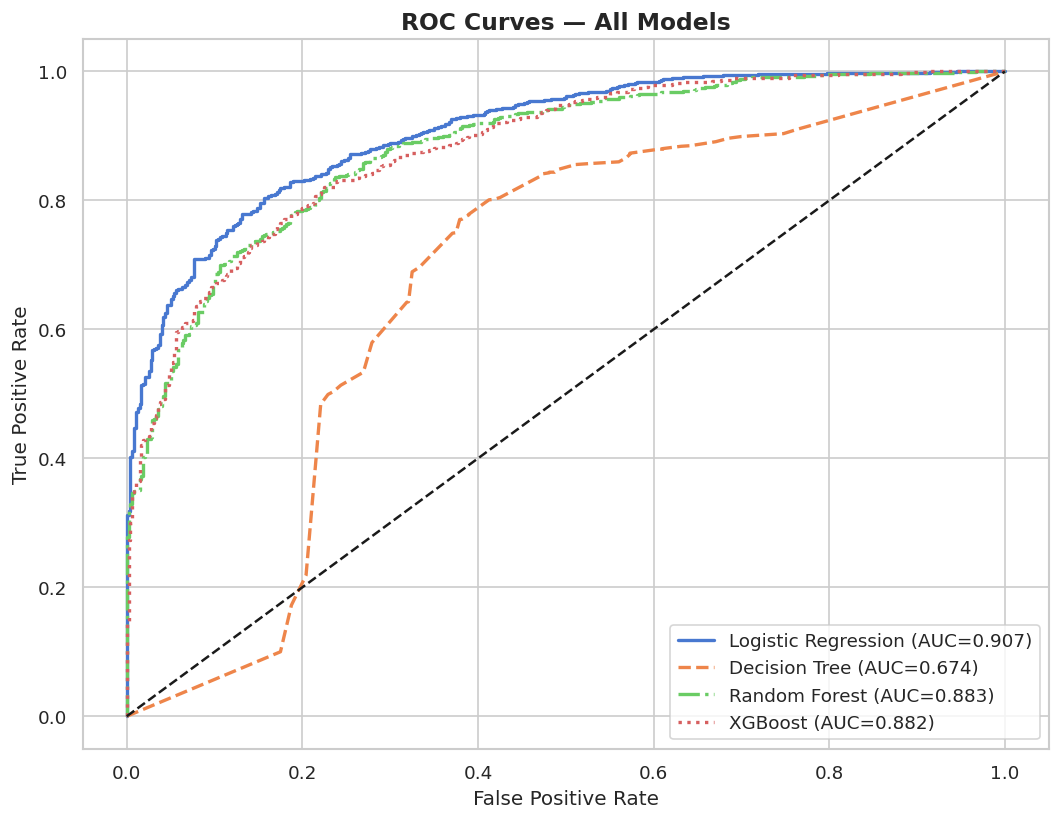

In [89]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))
line_styles = ['-', '--', '-.', ':']
for (name, vals), ls in zip(results.items(), line_styles):
    y_proba = vals['model_obj'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = vals['ROC-AUC']
    ax.plot(fpr, tpr, lw=2, ls=ls, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

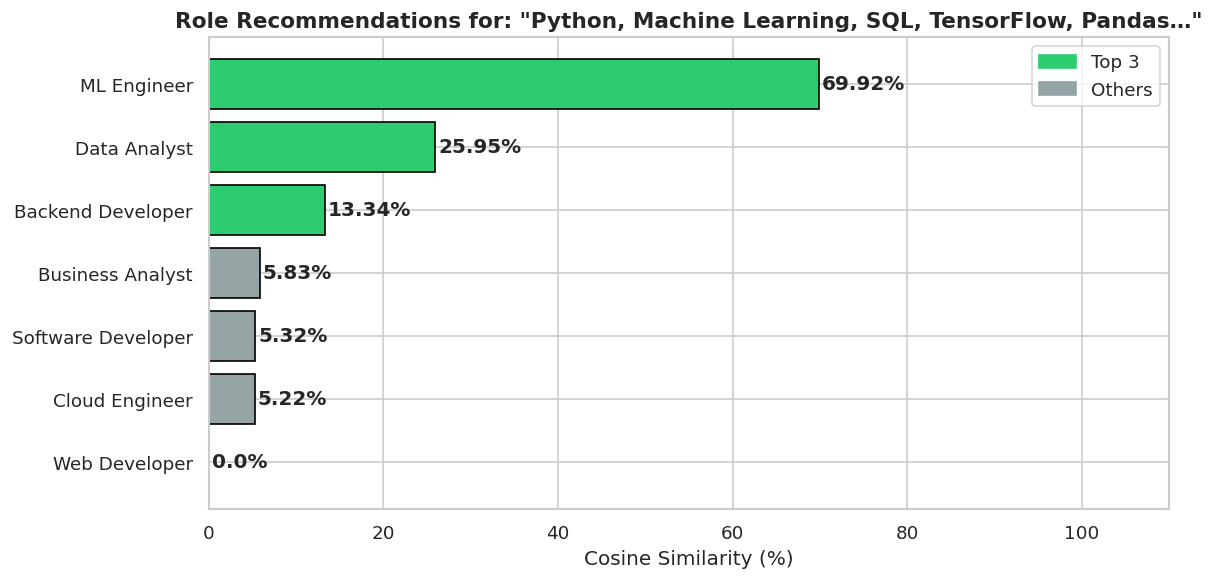

In [90]:
all_role_recs = recommend_roles(user_input['skills'], top_n=7)
rec_roles  = [r for r, _ in all_role_recs]
rec_scores = [s for _, s in all_role_recs]

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#2ECC71' if i < 3 else '#95A5A6' for i in range(len(rec_roles))]
bars = ax.barh(rec_roles[::-1], rec_scores[::-1],
               color=colors_bar[::-1], edgecolor='black')
for bar, val in zip(bars, rec_scores[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

ax.set_xlim(0, 110)
ax.set_xlabel('Cosine Similarity (%)', fontsize=12)
ax.set_title(f'Role Recommendations for: "{user_input["skills"][:50]}…"',
             fontsize=13, fontweight='bold')
green_p = mpatches.Patch(color='#2ECC71', label='Top 3')
grey_p  = mpatches.Patch(color='#95A5A6', label='Others')
ax.legend(handles=[green_p, grey_p])
plt.tight_layout()
plt.show()

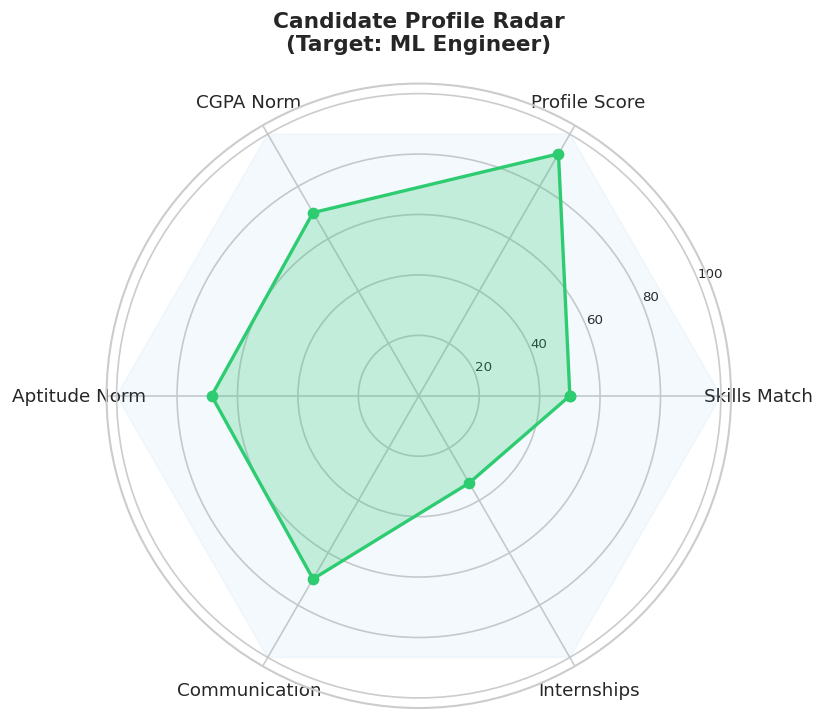

In [91]:
have_s, miss_s, cov = skill_gap_analysis(user_input['skills'], primary_role)

labels = ['Skills Match', 'Profile Score', 'CGPA Norm',
          'Aptitude Norm', 'Communication', 'Internships']

def norm(val, lo, hi): return (val - lo) / (hi - lo) * 100

user_vals = [
    cov,
    confidence,
    norm(user_input['cgpa'], 4, 10),
    norm(user_input['aptitude_score'], 30, 100),
    user_input['communication_skills'] * 10,
    user_input['internships'] / 3 * 100
]

N_cats  = len(labels)
angles  = np.linspace(0, 2 * np.pi, N_cats, endpoint=False).tolist()
user_vals_plot = user_vals + [user_vals[0]]
angles_plot    = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.fill(angles, user_vals, alpha=0.25, color='#2ECC71')
ax.plot(angles_plot, user_vals_plot, 'o-', lw=2, color='#2ECC71', label='Your Profile')
ax.fill(angles, [100]*N_cats, alpha=0.05, color='#3498DB')
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8)
ax.set_title(f'Candidate Profile Radar\n(Target: {primary_role})',
             fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## **Sample Predictions on Multiple Profiles**

In [92]:
sample_profiles = [
    {
        'name':         'Alice  (Strong ML Profile)',
        'skills':       'Python, Machine Learning, TensorFlow, SQL, Pandas, Deep Learning, NLP',
        'projects':     'Image Classifier, Sentiment Analysis, Recommendation Engine',
        'certifications': 'TensorFlow Developer, Coursera ML Specialization',
        'cgpa': 8.9, 'internships': 2, 'communication_skills': 8,
        'aptitude_score': 88, 'problem_solving': 9, 'role_interest': 'ML Engineer'
    },
    {
        'name':         'Bob    (Average Web Developer)',
        'skills':       'HTML, CSS, JavaScript, React',
        'projects':     'Portfolio Website',
        'certifications': 'None',
        'cgpa': 6.5, 'internships': 0, 'communication_skills': 5,
        'aptitude_score': 55, 'problem_solving': 5, 'role_interest': 'Web Developer'
    },
    {
        'name':         'Carol  (Strong Data Analyst)',
        'skills':       'Python, SQL, Excel, Tableau, Power BI, Statistics, R',
        'projects':     'Sales Dashboard, Data Pipeline',
        'certifications': 'IBM Data Science',
        'cgpa': 7.8, 'internships': 1, 'communication_skills': 7,
        'aptitude_score': 72, 'problem_solving': 7, 'role_interest': 'Data Analyst'
    },
    {
        'name':         'Dave   (Weak Profile)',
        'skills':       'HTML',
        'projects':     'None',
        'certifications': 'None',
        'cgpa': 4.5, 'internships': 0, 'communication_skills': 3,
        'aptitude_score': 35, 'problem_solving': 2, 'role_interest': 'Software Developer'
    },
    {
        'name':         'Eve    (Cloud Engineer)',
        'skills':       'AWS, Docker, Kubernetes, Terraform, Linux, Python, CI/CD',
        'projects':     'Cloud Deployment, REST API Service',
        'certifications': 'AWS Certified, Google Cloud Certified',
        'cgpa': 8.1, 'internships': 2, 'communication_skills': 7,
        'aptitude_score': 80, 'problem_solving': 8, 'role_interest': 'Cloud Engineer'
    },
]

print(f'{"Profile":<35} {"Job Ready":<12} {"Confidence":>12}  Top Role')
print('-' * 80)

for p in sample_profiles:
    u_s = tfidf_skills.transform([p['skills']])
    u_p = tfidf_proj  .transform([p['projects']])
    u_c = tfidf_cert  .transform([p['certifications']])

    role_enc_p = le_role.transform([p['role_interest']])[0] \
                 if p['role_interest'] in known_roles else 0

    u_n_raw = pd.DataFrame([{
        'CGPA': p['cgpa'], 'Internships': p['internships'],
        'Communication_Skills': p['communication_skills'],
        'Aptitude_Score': p['aptitude_score'],
        'Problem_Solving': p['problem_solving'],
        'Role_Interest_Enc': role_enc_p
    }])
    u_n   = csr_matrix(scaler.transform(u_n_raw))
    X_p   = hstack([u_s, u_p, u_c, u_n])

    pred  = final_model.predict(X_p)[0]
    conf  = final_model.predict_proba(X_p)[0][1] * 100
    lbl   = le_target.inverse_transform([pred])[0]
    icon  = '✅' if lbl == 'Yes' else '❌'
    top_r = recommend_roles(p['skills'], top_n=1)[0][0]

    print(f'{p["name"]:<35} {icon} {lbl:<9}  {conf:>9.1f}%   {top_r}')

Profile                             Job Ready      Confidence  Top Role
--------------------------------------------------------------------------------
Alice  (Strong ML Profile)          ✅ Yes             99.9%   ML Engineer
Bob    (Average Web Developer)      ❌ No               0.8%   Web Developer
Carol  (Strong Data Analyst)        ✅ Yes             94.6%   Data Analyst
Dave   (Weak Profile)               ❌ No               0.0%   Web Developer
Eve    (Cloud Engineer)             ✅ Yes             99.0%   Cloud Engineer
